<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/Week2%263/Week2_Bibit_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 2 - Exploratory Data Analysis**

1. Setup dan Instalasi

Import library yang dibutuhkan untuk analisis data dan visualisasi.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Load Dataset


Memuat dataset ulasan Bibit dari Google Drive ke dalam DataFrame pandas.

**Kolom utama:**
| Kolom | Keterangan |
|---|---|
| `reviewId` | ID unik setiap ulasan |
| `userName` | Nama pengguna |
| `content` | Teks ulasan |
| `score` | Rating (1–5) |
| `thumbsUpCount` | Jumlah *thumbs up* |
| `reviewCreatedVersion` | Versi aplikasi saat ulasan dibuat |
| `at` | Timestamp ulasan |
| `replyContent` | Balasan dari developer |
| `repliedAt` | Timestamp balasan |
| `appVersion` | Versi aplikasi |

In [ ]:
df_review = pd.read_csv('/content/drive/MyDrive/NLP/bibit_review.csv')
df_review

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7a1e7ff5-5f01-4a1a-a243-94297453c196,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,5,0,3.106.1,2026-03-30 05:08:53,Terima kasih Kak Imam telah memilih Bibit seba...,2026-03-30 06:09:03,3.106.1
1,7c05c1c8-8548-4ce3-99ff-55fa773e237c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,okelah buat nabung,5,0,3.106.2,2026-03-30 01:40:09,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:07,3.106.2
2,5fe28643-10fc-4082-8cb0-c6d24867137e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Apk rekomendasi untuk pemula yang ingin tau te...,5,0,3.106.2,2026-03-30 01:38:55,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:03,3.106.2
3,994552cc-8b6e-4156-bdbe-e1899a611f8f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,3.106.1,2026-03-29 17:29:32,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:00,3.106.1
4,eabc7e21-249d-424c-b6de-d61308016aba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,3.106.1,2026-03-29 14:31:37,Terima kasih atas kepercayaan & kesetiaan kaka...,2026-03-29 16:22:37,3.106.1
...,...,...,...,...,...,...,...,...,...,...,...
49053,0dc6339f-abba-43d9-afe5-746de3ddc4db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"bgus nih aplikasi ,jdi lebih mudah pilih sama ...",5,2,NaN,2019-01-11 10:00:42,NaN,NaN,NaN
49054,3e96d1f4-a4ba-4d76-83b9-bf153bf07189,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Daripada taro duit di bank dimana bunga rendah...,5,4,1.1.0,2019-01-11 08:58:00,NaN,NaN,1.1.0
49055,fbcc0662-445c-4054-b446-77730664dfc9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Design nya sangat bagus, dan membuat investasi...",5,4,1.1.0,2019-01-11 08:53:13,NaN,NaN,1.1.0
49056,8db8cabb-5722-4300-9954-2d62a2437a54,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mantap bibit,5,0,1.1.0,2019-01-11 02:43:56,NaN,NaN,1.1.0


In [ ]:
df_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49058 entries, 0 to 49057
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              49058 non-null  object
 1   userName              49058 non-null  object
 2   userImage             49058 non-null  object
 3   content               49058 non-null  object
 4   score                 49058 non-null  int64 
 5   thumbsUpCount         49058 non-null  int64 
 6   reviewCreatedVersion  42081 non-null  object
 7   at                    49058 non-null  object
 8   replyContent          10546 non-null  object
 9   repliedAt             10546 non-null  object
 10  appVersion            42081 non-null  object
dtypes: int64(2), object(9)
memory usage: 4.1+ MB


In [ ]:
df_review.describe()

,score,thumbsUpCount
count,49058.000000,49058.000000
mean,4.229218,1.951017
std,1.369958,21.432912
min,1.000000,0.000000
25%,4.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,0.000000
max,5.000000,2222.000000


In [ ]:
#missing value (null)
missing = df_review.isnull().sum()
missing

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,6977
at,0
replyContent,38512
repliedAt,38512


In [ ]:
# Duplicate reviews check
dup_reviewid = df_review['reviewId'].duplicated().sum()
dup_content = df_review['content'].duplicated().sum()

print(f'Duplicate reviewIds   : {dup_reviewid:,}')
print(f'Duplicate content text: {dup_content:,}')

# Show examples of duplicated content (if any)
if dup_content > 0:
    print(f'\nTop 5 most repeated review texts:')
    print(df_review['content'].value_counts().head())

Duplicate reviewIds   : 0
Duplicate content text: 11,289

Top 5 most repeated review texts:
content
Mantap    1032
mantap     644
Good       558
bagus      549
Ok         542
Name: count, dtype: int64


In [ ]:
count = df_review['score'].value_counts().sort_index()
df_count = pd.DataFrame(count).reset_index()
df_count.columns = ['score', 'count']
df_count = df_count[['score', 'count']]
df_count

,score,count
0,1,5808
1,2,1446
2,3,2515
3,4,5213
4,5,34076


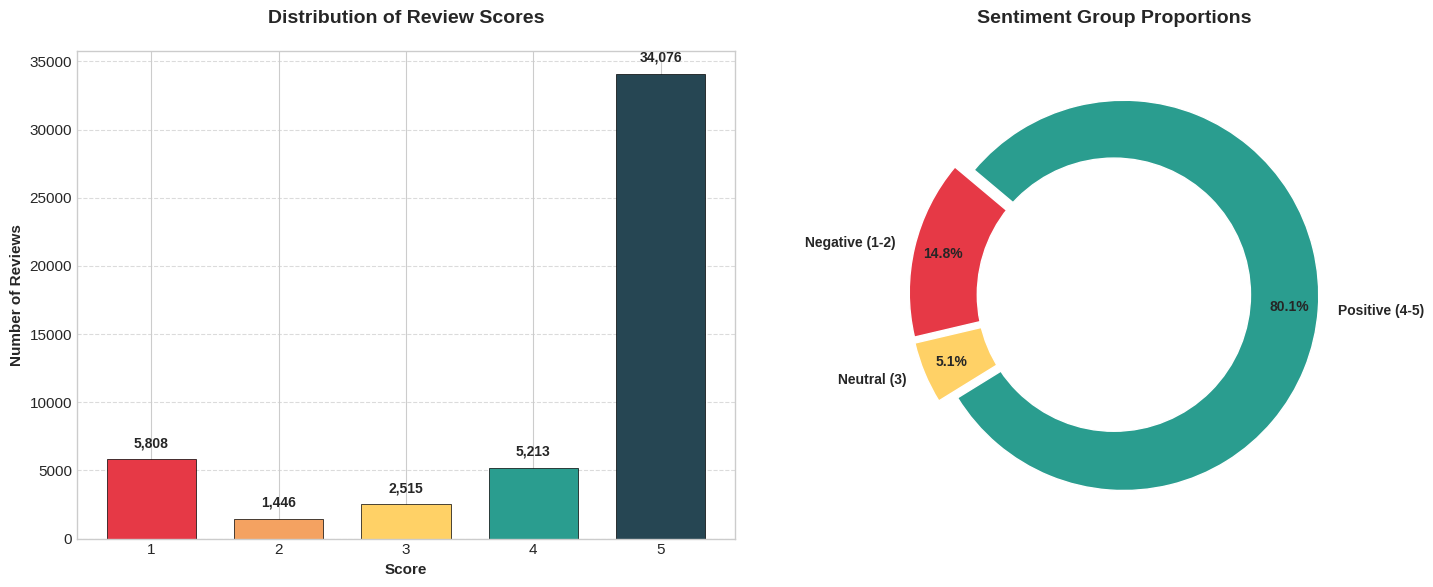

In [ ]:
df_count = df_review['score'].value_counts().sort_index().reset_index()
df_count.columns = ['score', 'count']

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = ['#E63946', '#F4A261', '#FFD166', '#2A9D8F', '#264653']
bars = axes[0].bar(df_count['score'], df_count['count'], color=colors, width=0.7, edgecolor='black', linewidth=0.5)

axes[0].set_xlabel('Score', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Reviews', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Review Scores', fontsize=14, pad=20, fontweight='bold')
axes[0].set_xticks(range(1, 6))
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + (max(df_count['count']) * 0.02),
                 f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

negative = df_count[df_count['score'].isin([1, 2])]['count'].sum()
neutral  = df_count[df_count['score'] == 3]['count'].sum()
positive = df_count[df_count['score'].isin([4, 5])]['count'].sum()

labels = ['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)']
sizes = [negative, neutral, positive]
pie_colors = ['#E63946', '#FFD166', '#2A9D8F']

wedges, texts, autotexts = axes[1].pie(sizes, labels=labels, colors=pie_colors, autopct='%1.1f%%',
                                      startangle=140, pctdistance=0.85, explode=(0.05, 0.05, 0.05),
                                      textprops={'fontsize': 10, 'fontweight': 'bold'})

centre_circle = plt.Circle((0,0), 0.70, fc='white')
axes[1].add_artist(centre_circle)

axes[1].set_title('Sentiment Group Proportions', fontsize=14, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
yearly = df_review.groupby('year').agg(
    review_count=('content', 'count'),
    avg_score=('score', 'mean')
).round(2)

print('Yearly Summary:')
yearly

Yearly Summary:


,review_count,avg_score
year,,
2019,4295,4.58
2020,15973,4.66
2021,11069,4.03
2022,7527,3.88
2023,3522,3.96
2024,2605,3.87
2025,3034,3.87
2026,1033,3.66


In [ ]:
df_review['at'] = pd.to_datetime(df_review['at'])
df_review['year'] = df_review['at'].dt.year

print(f'Review date range: {df_review["at"].min().date()} to {df_review["at"].max().date()}')
print(f'Total span: {(df_review["at"].max() - df_review["at"].min()).days:,} days')

Review date range: 2019-01-10 to 2026-03-30
Total span: 2,635 days


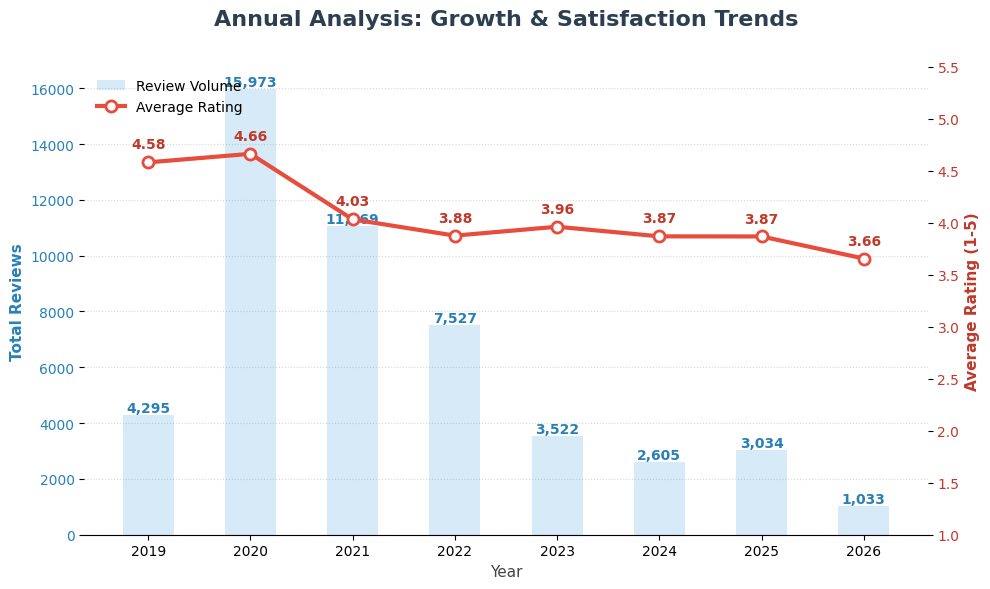

In [ ]:
#yearly Review Visualization
yearly = df_review.groupby('year').agg(
    review_count=('content', 'count'),
    avg_score=('score', 'mean')
).reset_index()

plt.style.use('default')
fig, ax1 = plt.subplots(figsize=(10, 6), facecolor='white')

ax1.set_facecolor('white')
bars = ax1.bar(yearly['year'], yearly['review_count'], width=0.5,
               color='#3498db', alpha=0.2, label='Review Volume', zorder=2)

ax1.set_xlabel('Year', fontsize=11, color='#444444')
ax1.set_ylabel('Total Reviews', color='#2980b9', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax1.set_xticks(yearly['year'])
ax1.grid(axis='y', linestyle=':', alpha=0.5, zorder=1)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height):,}', ha='center', va='bottom',
             fontsize=10, color='#2980b9', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(yearly['year'], yearly['avg_score'], color='#e74c3c',
         linewidth=3, marker='o', markersize=8, markerfacecolor='white',
         markeredgewidth=2, label='Average Rating', zorder=3)

for i, txt in enumerate(yearly['avg_score']):
    ax2.annotate(f'{txt:.2f}', (yearly['year'][i], yearly['avg_score'][i]),
                 textcoords="offset points", xytext=(0, 10), ha='center',
                 fontsize=10, color='#c0392b', fontweight='bold')

ax2.set_ylabel('Average Rating (1-5)', color='#c0392b', fontsize=11, fontweight='bold')
ax2.set_ylim(1, 5.5)
ax2.tick_params(axis='y', labelcolor='#c0392b')

for spine in ['top', 'left', 'right']:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)
ax1.spines['bottom'].set_color('#dddddd')

plt.title('Annual Analysis: Growth & Satisfaction Trends',
          fontsize=16, pad=30, fontweight='bold', color='#2c3e50')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

Total unique app versions: 230
Reviews with missing version: 6,977


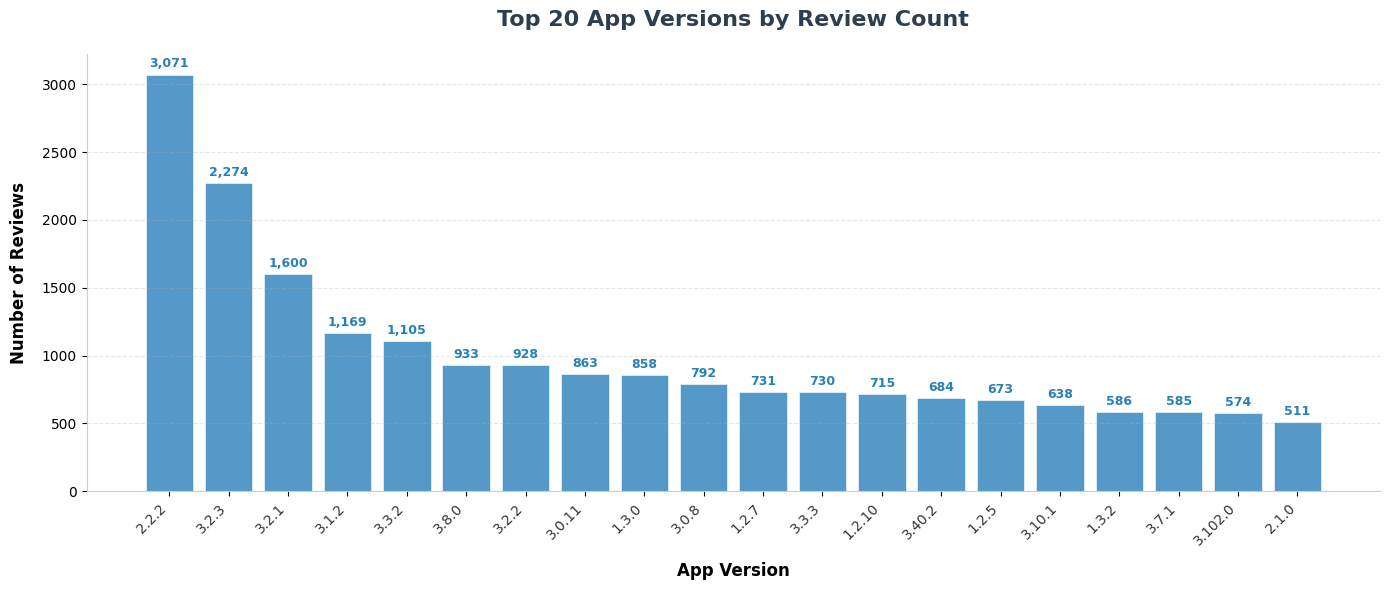

In [ ]:
#Number of Review by Version
version_counts = df_review['reviewCreatedVersion'].value_counts()
print(f'Total unique app versions: {version_counts.shape[0]}')
print(f'Reviews with missing version: {df_review["reviewCreatedVersion"].isna().sum():,}')

top_versions = version_counts.head(20)

plt.style.use('default')
fig, ax = plt.subplots(figsize=(14, 6), facecolor='white')

ax.set_facecolor('white')
bars = ax.bar(range(len(top_versions)), top_versions.values, color='#2980B9',
              edgecolor='white', linewidth=0.5, alpha=0.8)

ax.set_xticks(range(len(top_versions)))
ax.set_xticklabels(top_versions.index, rotation=45, ha='right', fontsize=10, color='#333333')
ax.set_xlabel('App Version', fontsize=12, labelpad=10, fontweight='bold')
ax.set_ylabel('Number of Reviews', fontsize=12, labelpad=10, fontweight='bold')
ax.set_title('Top 20 App Versions by Review Count', fontsize=16, pad=20, fontweight='bold', color='#2c3e50')

ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (max(top_versions.values) * 0.01),
            f'{int(height):,}', ha='center', va='bottom', fontsize=9,
            fontweight='bold', color='#2980B9')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

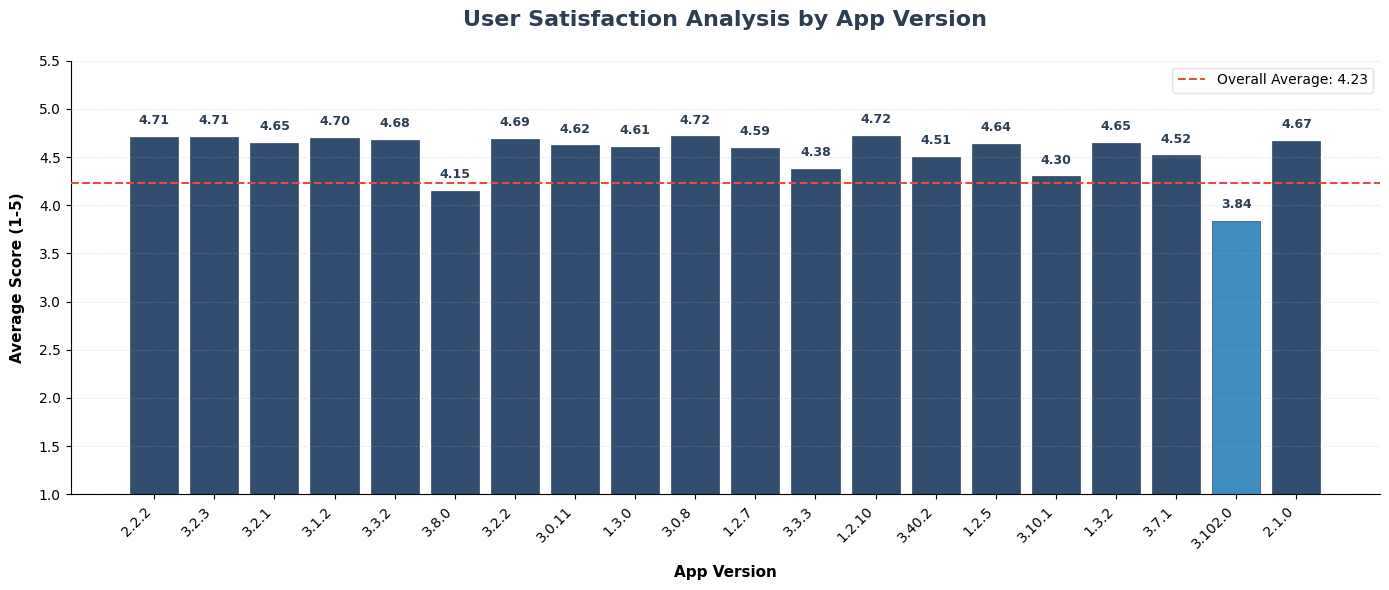

In [ ]:
#Avarage Review Score by Version
top_ver_list = top_versions.index.tolist()
ver_scores = df_review[df_review['reviewCreatedVersion'].isin(top_ver_list)].groupby('reviewCreatedVersion')['score'].agg(['mean', 'count'])
ver_scores = ver_scores.loc[top_ver_list]

overall_avg = df_review['score'].mean()

plt.style.use('default')
fig, ax = plt.subplots(figsize=(14, 6), facecolor='white')

def get_blue_shade(score):
    if score >= 4.0: return '#1A3A5F' # Deep Navy
    if score >= 3.0: return '#2980B9' # Strong Blue
    if score >= 2.0: return '#7FB3D5' # Soft Blue
    return '#D4E6F1'                # Very Light Blue

bar_colors = [get_blue_shade(s) for s in ver_scores['mean']]
bars = ax.bar(range(len(ver_scores)), ver_scores['mean'], color=bar_colors, alpha=0.9, edgecolor='#2C3E50', linewidth=0.5)

ax.axhline(y=overall_avg, color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Overall Average: {overall_avg:.2f}', zorder=3)

ax.set_xticks(range(len(ver_scores)))
ax.set_xticklabels(ver_scores.index, rotation=45, ha='right', fontsize=10)
ax.set_xlabel('App Version', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Average Score (1-5)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylim(1, 5.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2C3E50')

ax.set_title('User Satisfaction Analysis by App Version', fontsize=16, pad=25, fontweight='bold', color='#2C3E50')

ax.grid(axis='y', linestyle=':', alpha=0.4, zorder=0)
ax.set_facecolor('white')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=True, facecolor='white', edgecolor='#dddddd', loc='upper right')

plt.tight_layout()
plt.show()